In [13]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import matplotlib

In [14]:
df = pd.read_csv('nr_ic_merged.csv')

In [15]:
# Keep only valid SMILES
def smiles_to_mol(s):
    if pd.isna(s) or str(s).lower() == 'nan':
        return None
    try:
        return Chem.MolFromSmiles(str(s))
    except Exception:
        return None


df['mol'] = df['Smiles'].map(smiles_to_mol)
df = df[df['mol'].notna()].copy()

In [16]:
FPSIZE = 4096
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FPSIZE)

def mol_to_fp(mol):
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((FPSIZE,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

df['fp'] = df['mol'].map(mol_to_fp)

In [17]:
encoder = OneHotEncoder(sparse_output=False)
target_encoded = encoder.fit_transform(df[['Target']])
target_names = encoder.categories_[0]

df['target_encoded'] = target_encoded.tolist()

In [18]:
df['fp_tuple'] = df['fp'].apply(lambda x: tuple(x))

# Group by fingerprint and OR-combine their one-hot target vectors
grouped = df.groupby('fp_tuple')['target_encoded'].apply(
    lambda rows: np.any(np.vstack(rows.values), axis=0).astype(int)
)

df_agg = grouped.reset_index()

# Convert fp back to numpy array
df_agg['fp'] = df_agg['fp_tuple'].apply(lambda x: np.array(x))
df_agg = df_agg.rename(columns={'target_encoded': 'target'})
df_agg = df_agg.drop(columns=['fp_tuple'])

In [19]:
x = np.vstack(df_agg['fp'].values)
y = np.vstack(df_agg['target'].values)

In [20]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [21]:
xgb_estimator = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    n_jobs=-1,
    random_state=42,
    tree_method="hist",
    eval_metric="logloss",
)

model = OneVsRestClassifier(xgb_estimator)
model.fit(x_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,n_jobs,None
,verbose,0
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None


In [22]:
y_pred_prob_matrix = model.predict_proba(x_test)

# Calculate ROC-AUC per target
roc_auc_per_target = []
for i in range(y_test.shape[1]):
    try:
        score = roc_auc_score(y_test[:, i], y_pred_prob_matrix[:, i])
        roc_auc_per_target.append(score)
    except ValueError:
        # Handle cases where a target might only have one class in test set
        roc_auc_per_target.append(0.5)

print("ROC-AUC per target:", roc_auc_per_target)
print("Mean ROC-AUC:", np.mean(roc_auc_per_target))

ROC-AUC per target: [0.9698394077089705, 0.9818622020956853, 0.9736752952871773, 0.9892850069320658, 0.9829793381751578, 0.9600207481194487]
Mean ROC-AUC: 0.9762769997197509


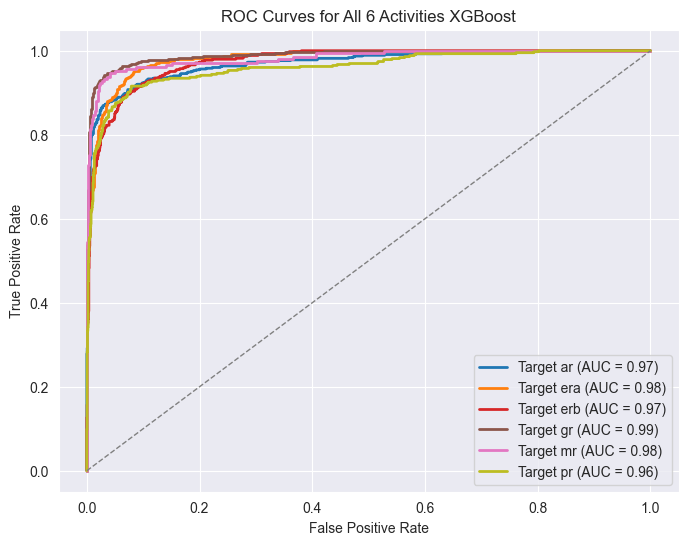

In [24]:
n_targets = y_test.shape[1]
cmap = matplotlib.colormaps.get_cmap('tab10')

plt.figure(figsize=(8, 6))

for i in range(n_targets):
    fpr, tpr, thresholds = roc_curve(y_test[:, i], y_pred_prob_matrix[:, i])
    auc_score = roc_auc_per_target[i]
    color = cmap(i / n_targets) if n_targets > 1 else 'blue'

    label = f"Target {target_names[i]} (AUC = {auc_score:.2f})"
    plt.plot(fpr, tpr, color=color, lw=2, label=label)

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All 6 Activities XGBoost")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()